In [109]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Credit Risk Assessment

In [110]:
import pandas as pd
import numpy as np

import src.utils as utils

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## Exploratory Data Analysis

In [111]:
df_train = pd.read_parquet('input/df_train.parquet')
X_train = df_train.drop(columns=['loan_status'])
y_train = df_train['loan_status']
utils.skim_data(df_train)

Total duplicate rows: 0
DF shape: (191130, 28)


,feature,dtype,null_%,negative_%,zero_%,n_unique,unique_%,sample_values
0,loan_amnt,int64,0.000,0.0,0.0,1291,0.68,"[6000, 9250, 15600, 15000, 1050]"
1,funded_amnt,int64,0.000,0.0,0.0,1294,0.68,"[6000, 9250, 15600, 15000, 1050]"
2,funded_amnt_inv,float64,0.000,0.0,0.102,7916,4.14,"[6000.0, 9250.0, 15600.0, 15000.0, 1050.0]"
3,term,object,0.000,-,-,2,0.00,"[ 36 months, 60 months]"
4,int_rate,float64,0.000,0.0,0.0,503,0.26,"[19.2, 15.31, 8.39, 14.49, 14.72]"
5,installment,float64,0.000,0.0,0.0,39733,20.79,"[220.55, 322.07, 491.66, 352.85, 36.26]"
6,sub_grade,object,0.000,-,-,35,0.02,"[D3, C2, A5, C4, C5]"
7,emp_length,object,3.881,-,-,11,0.01,"[9 years, 10+ years, 4 years, 1 year, 8 years]"
8,home_ownership,object,0.000,-,-,6,0.00,"[OWN, RENT, MORTGAGE, OTHER, NONE]"
9,annual_inc,float64,0.002,0.0,0.0,15749,8.24,"[60000.0, 27600.0, 75000.0, 80000.0, 36000.0]"


In [112]:
df_test = pd.read_parquet('input/df_test.parquet')
utils.skim_data(df_test)

Total duplicate rows: 0
DF shape: (47783, 28)


,feature,dtype,null_%,negative_%,zero_%,n_unique,unique_%,sample_values
0,loan_amnt,int64,0.000,0.0,0.0,1148,2.40,"[5500, 15000, 24000, 9200, 30000]"
1,funded_amnt,int64,0.000,0.0,0.0,1160,2.43,"[5500, 15000, 24000, 9200, 30000]"
2,funded_amnt_inv,float64,0.000,0.0,0.082,2954,6.18,"[5500.0, 15000.0, 24000.0, 9200.0, 30000.0]"
3,term,object,0.000,-,-,2,0.00,"[ 36 months, 60 months]"
4,int_rate,float64,0.000,0.0,0.0,481,1.01,"[14.09, 7.62, 12.12, 6.03, 9.76]"
5,installment,float64,0.000,0.0,0.0,18757,39.25,"[188.22, 467.43, 798.52, 456.54, 295.83]"
6,sub_grade,object,0.000,-,-,35,0.07,"[B5, A3, B3, A1, B1]"
7,emp_length,object,3.784,-,-,11,0.02,"[7 years, 10+ years, < 1 year, 4 years, 1 year]"
8,home_ownership,object,0.000,-,-,5,0.01,"[RENT, OWN, MORTGAGE, OTHER, NONE]"
9,annual_inc,float64,0.000,0.0,0.0,5261,11.01,"[67204.0, 70000.0, 90000.0, 58000.0, 25000.0]"


### High-Multicollinearity Features

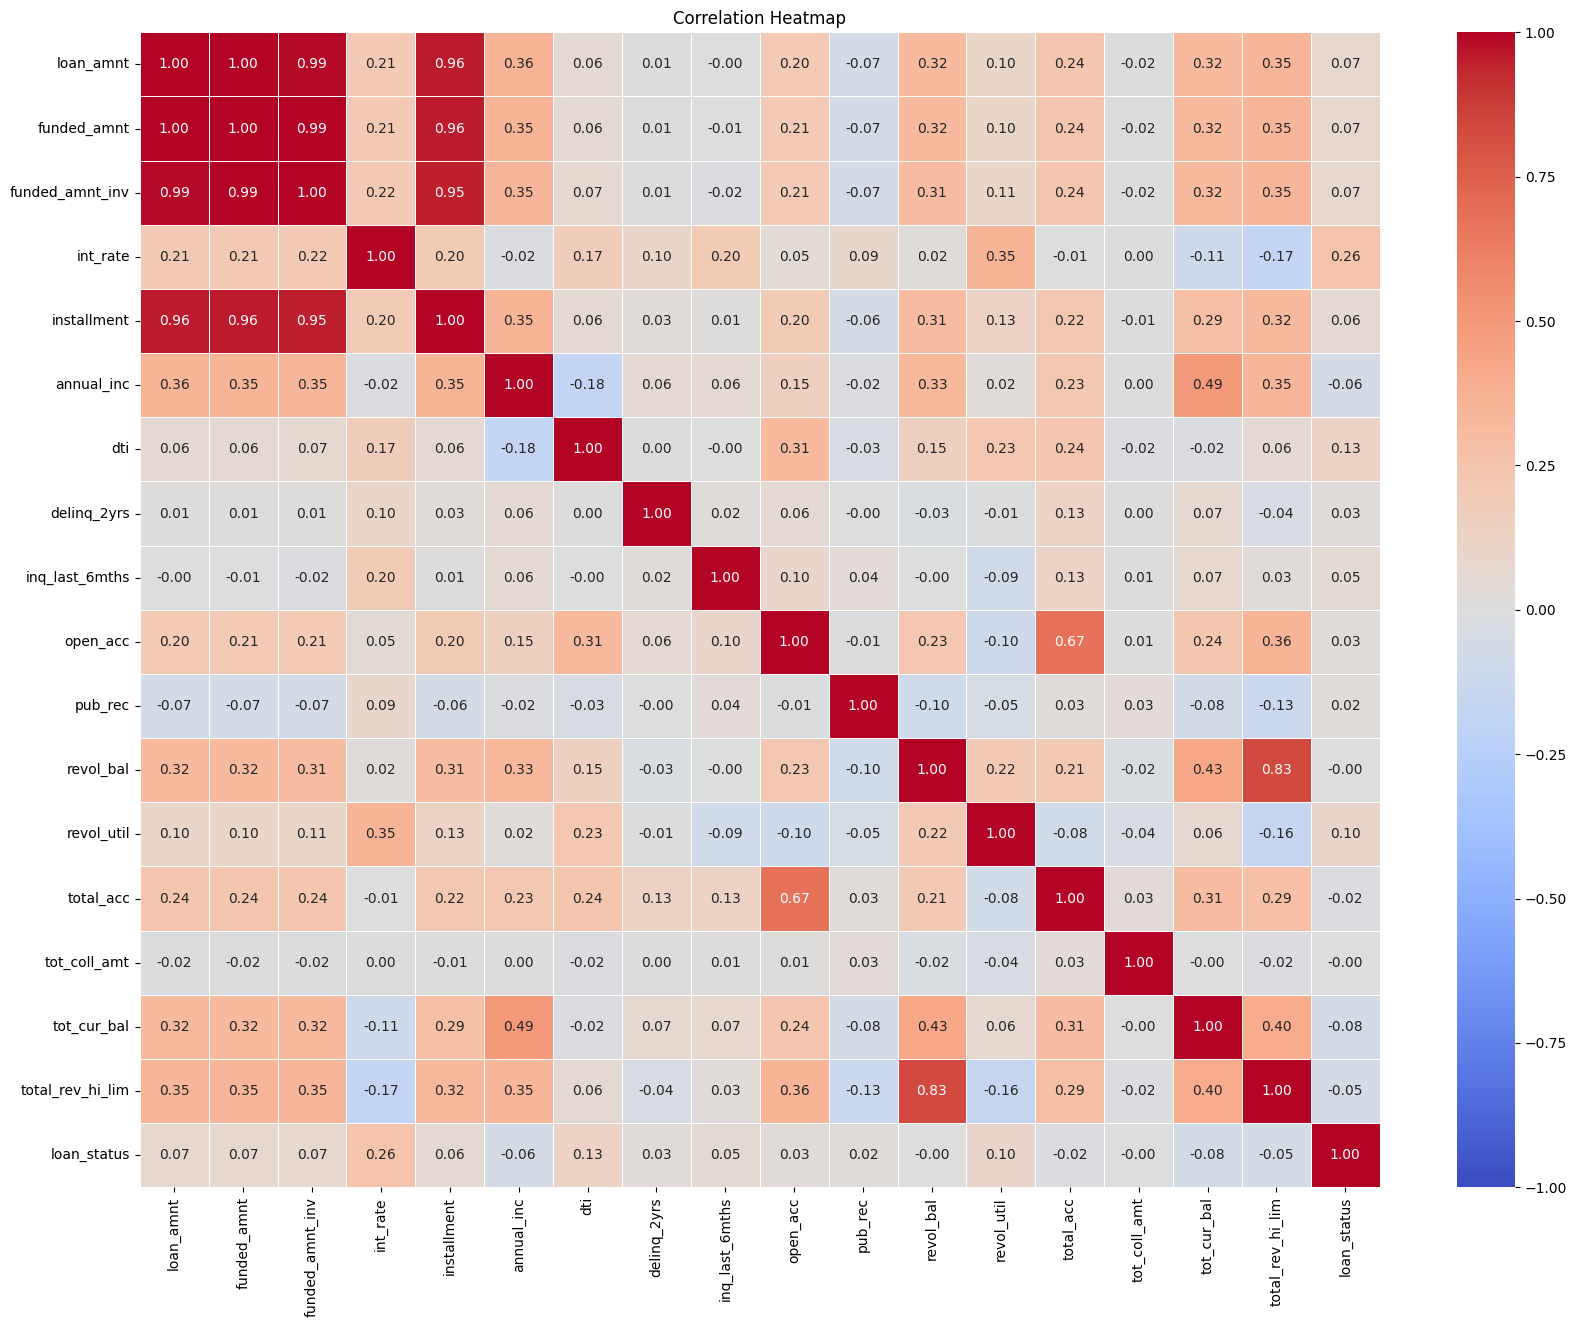

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df_train.select_dtypes(include=[np.number]).columns
corr_matrix = df_train[numeric_cols].corr()
plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            vmin=-1, vmax=1,
            linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [114]:
features_to_drop = ['funded_amnt', 'funded_amnt_inv', 'installment']
df_train = df_train.drop(columns=features_to_drop)
df_test = df_test.drop(columns=features_to_drop)

In [115]:
utils.skim_data(df_train)

Total duplicate rows: 0
DF shape: (191130, 25)


,feature,dtype,null_%,negative_%,zero_%,n_unique,unique_%,sample_values
0,loan_amnt,int64,0.000,0.0,0.0,1291,0.68,"[6000, 9250, 15600, 15000, 1050]"
1,term,object,0.000,-,-,2,0.00,"[ 36 months, 60 months]"
2,int_rate,float64,0.000,0.0,0.0,503,0.26,"[19.2, 15.31, 8.39, 14.49, 14.72]"
3,sub_grade,object,0.000,-,-,35,0.02,"[D3, C2, A5, C4, C5]"
4,emp_length,object,3.881,-,-,11,0.01,"[9 years, 10+ years, 4 years, 1 year, 8 years]"
5,home_ownership,object,0.000,-,-,6,0.00,"[OWN, RENT, MORTGAGE, OTHER, NONE]"
6,annual_inc,float64,0.002,0.0,0.0,15749,8.24,"[60000.0, 27600.0, 75000.0, 80000.0, 36000.0]"
7,verification_status,object,0.000,-,-,3,0.00,"[Verified, Not Verified, Source Verified]"
8,purpose,object,0.000,-,-,14,0.01,"[home_improvement, credit_card, debt_consolida..."
9,addr_state,object,0.000,-,-,50,0.03,"[NY, AZ, SC, MI, CT]"


In [116]:
# save to file
df_train.to_parquet('input/df_train_02.parquet')
df_test.to_parquet('input/df_test_02.parquet')

### Skewness Check

In [117]:
def skewness_check(X):
    numeric_cols = X.select_dtypes(include=[np.number]).columns
    comparison = pd.DataFrame({
        'mean': X[numeric_cols].mean(),
        'median': X[numeric_cols].median()
    })
    comparison['skew_direction'] = comparison.apply(
        lambda x: 'Right Skewed (+)' if x['mean'] > x['median'] else 'Left Skewed (-)', axis=1
    )
    comparison['diff_percent'] = ((comparison['mean'] - comparison['median']) / comparison['median']) * 100
    display(comparison)

skewness_check(df_train)

,mean,median,skew_direction,diff_percent
loan_amnt,13479.291451,12000.00,Right Skewed (+),12.327429
int_rate,13.855577,13.67,Right Skewed (+),1.357552
annual_inc,71916.666492,61300.00,Right Skewed (+),17.319195
dti,16.437297,16.14,Right Skewed (+),1.841991
delinq_2yrs,0.248255,0.00,Right Skewed (+),inf
inq_last_6mths,0.905445,1.00,Left Skewed (-),-9.455485
open_acc,10.847357,10.00,Right Skewed (+),8.473570
pub_rec,0.135004,0.00,Right Skewed (+),inf
revol_bal,15205.812583,10982.00,Right Skewed (+),38.461233
revol_util,55.021357,56.70,Left Skewed (-),-2.960570


In [118]:
utils.skim_data(df_train)

Total duplicate rows: 0
DF shape: (191130, 25)


,feature,dtype,null_%,negative_%,zero_%,n_unique,unique_%,sample_values
0,loan_amnt,int64,0.000,0.0,0.0,1291,0.68,"[6000, 9250, 15600, 15000, 1050]"
1,term,object,0.000,-,-,2,0.00,"[ 36 months, 60 months]"
2,int_rate,float64,0.000,0.0,0.0,503,0.26,"[19.2, 15.31, 8.39, 14.49, 14.72]"
3,sub_grade,object,0.000,-,-,35,0.02,"[D3, C2, A5, C4, C5]"
4,emp_length,object,3.881,-,-,11,0.01,"[9 years, 10+ years, 4 years, 1 year, 8 years]"
5,home_ownership,object,0.000,-,-,6,0.00,"[OWN, RENT, MORTGAGE, OTHER, NONE]"
6,annual_inc,float64,0.002,0.0,0.0,15749,8.24,"[60000.0, 27600.0, 75000.0, 80000.0, 36000.0]"
7,verification_status,object,0.000,-,-,3,0.00,"[Verified, Not Verified, Source Verified]"
8,purpose,object,0.000,-,-,14,0.01,"[home_improvement, credit_card, debt_consolida..."
9,addr_state,object,0.000,-,-,50,0.03,"[NY, AZ, SC, MI, CT]"


### Outliers

Ditemukan 14 kolom numerik untuk dianalisis.


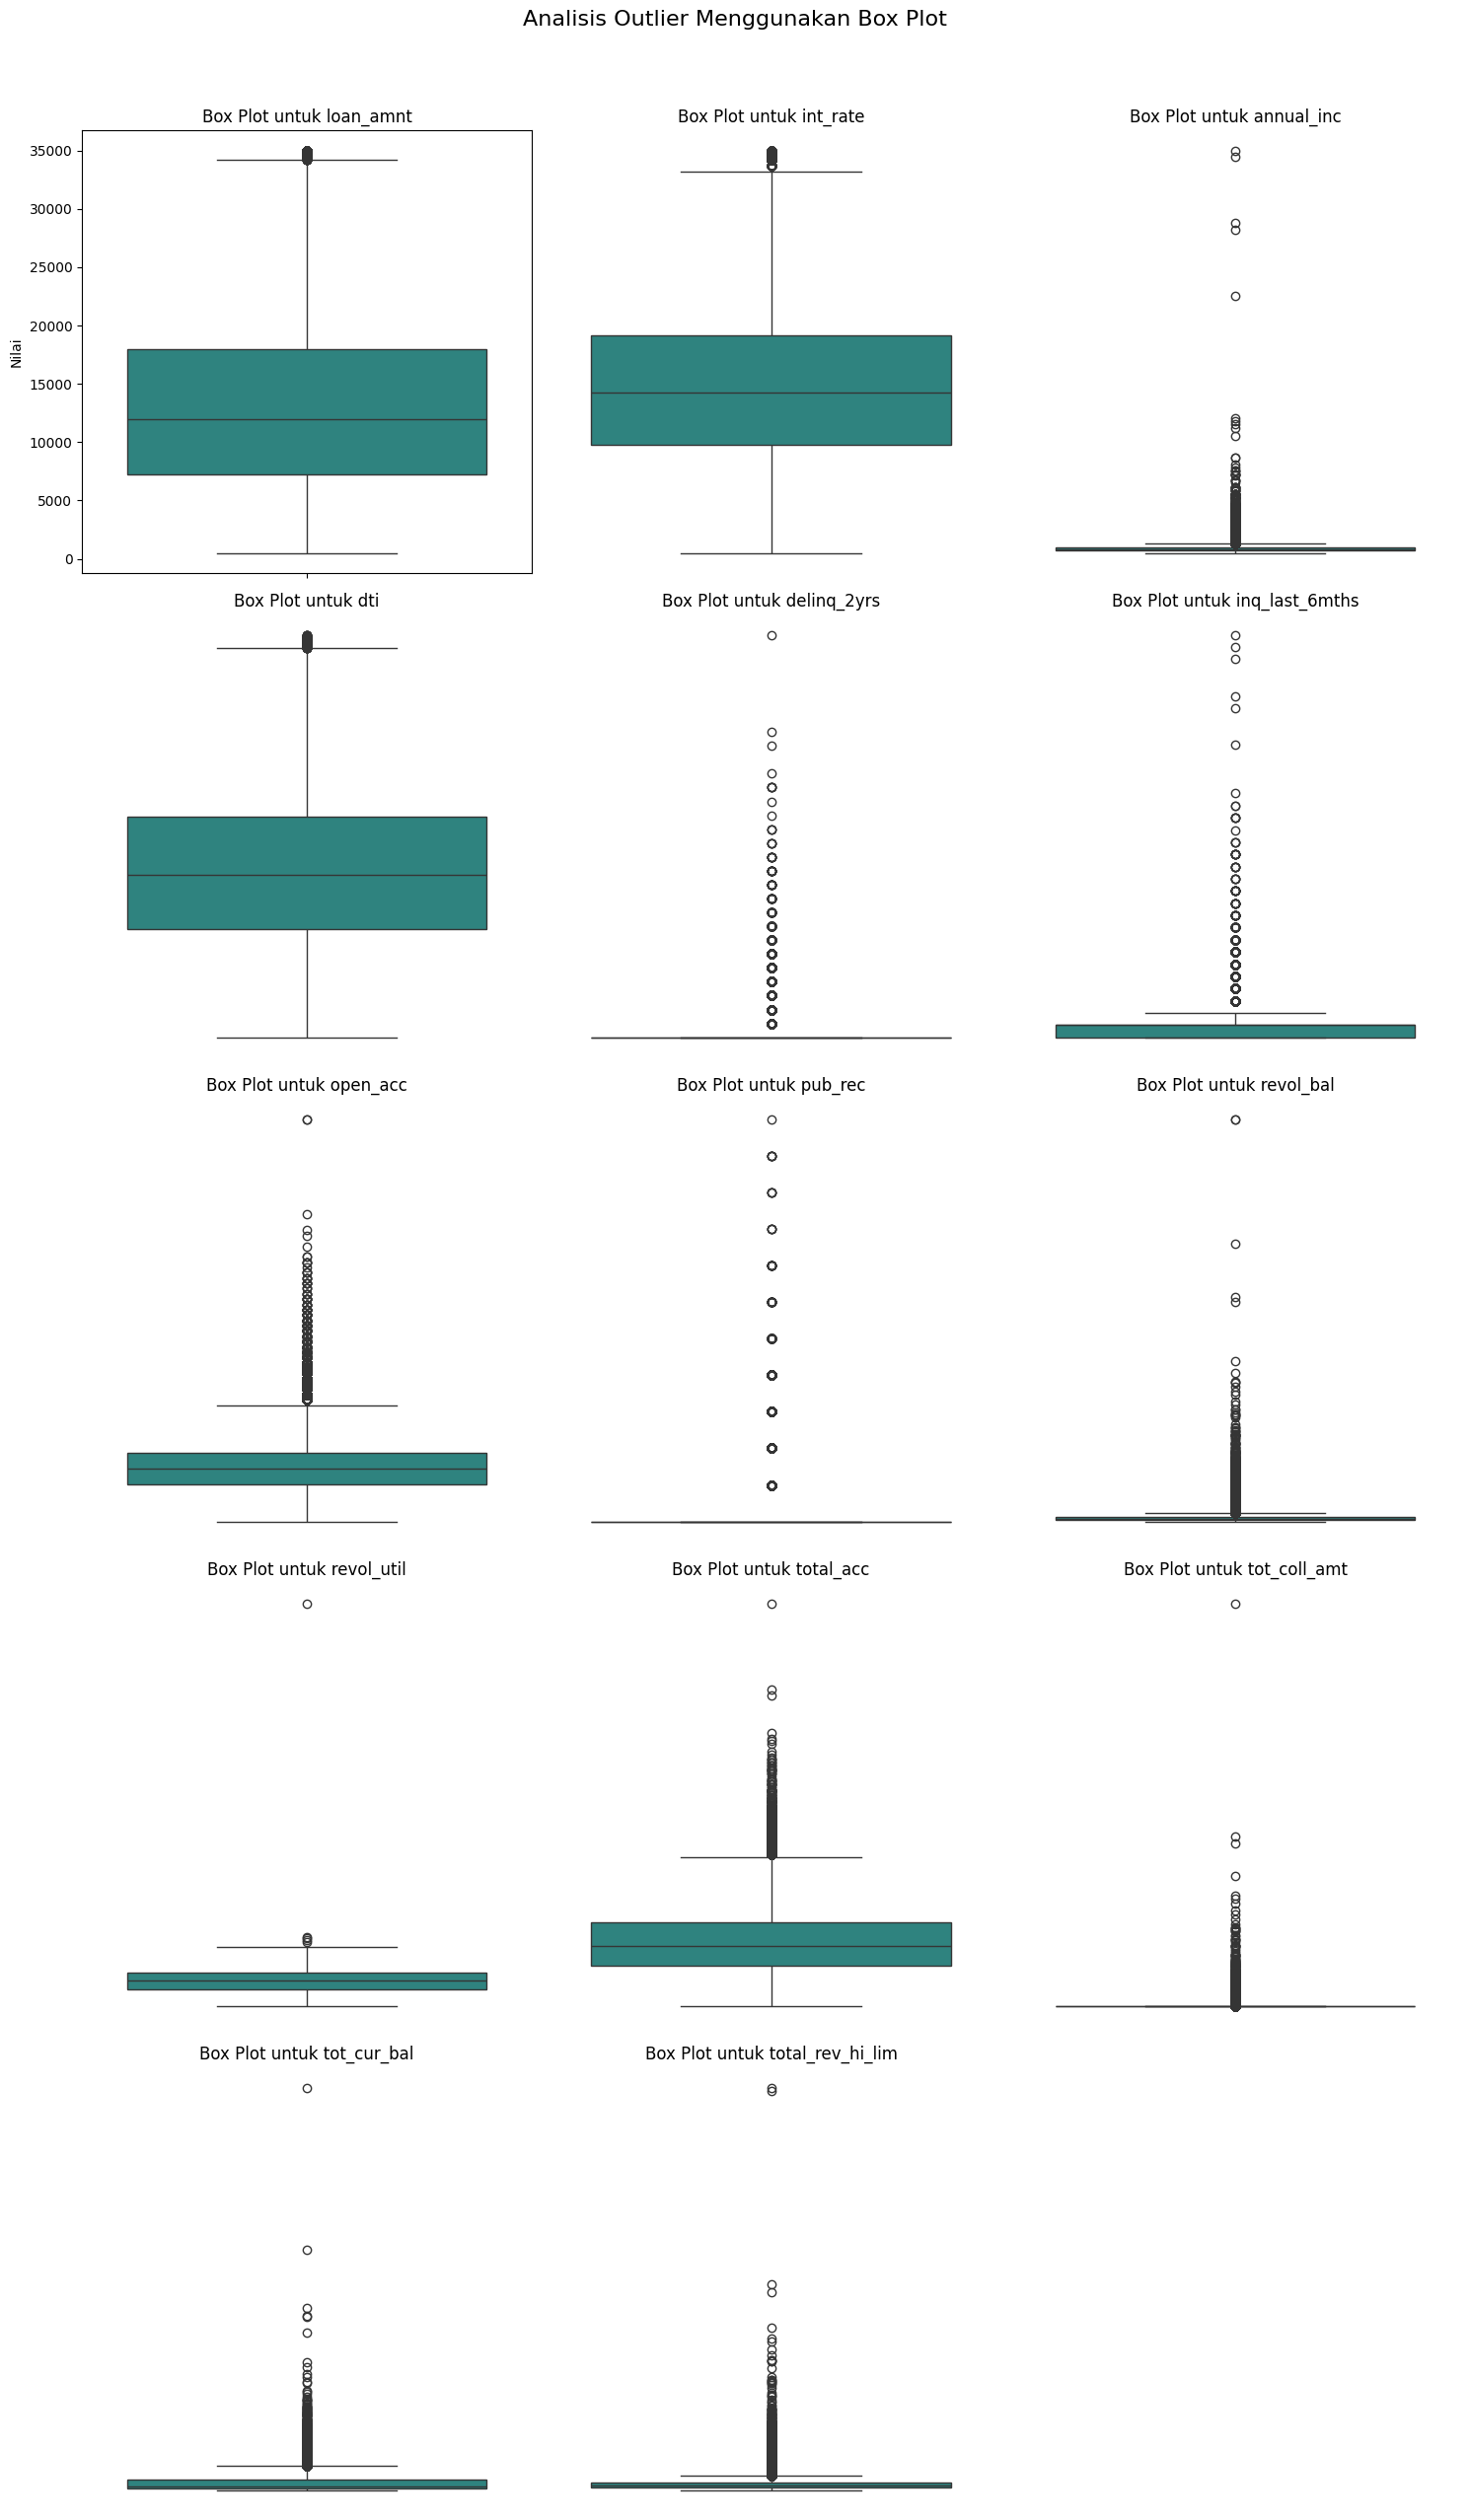

In [119]:
import math

numeric_features = df_train.select_dtypes(include=np.number).columns.tolist()
numeric_features = [i for i in numeric_features if i != 'loan_status']
print(f"Ditemukan {len(numeric_features)} kolom numerik untuk dianalisis.")

n_cols_grid = 3
n_rows_grid = math.ceil(len(numeric_features) / n_cols_grid)

fig, axes = plt.subplots(
    nrows=n_rows_grid, 
    ncols=n_cols_grid, 
    figsize=(15, 5 * n_rows_grid)
)
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(y=df_train[col], ax=axes[i], palette='viridis')
    axes[i].set_title(f'Box Plot untuk {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Nilai')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

plt.suptitle('Analisis Outlier Menggunakan Box Plot', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Beberapa fitur memiliki outlier, dan sebagian outlier tersebut terlihat memiliki jarak yang saling berdekatan. Saya melihat ada pertanda kalau pencatutan outlier yang menggunakan IQR masih terlalu rough untuk menentukan outlier, dan dapat diperbesar pengali untuk menentukan IQR.

In [120]:
utils.skim_data(df_train)

Total duplicate rows: 0
DF shape: (191130, 25)


,feature,dtype,null_%,negative_%,zero_%,n_unique,unique_%,sample_values
0,loan_amnt,int64,0.000,0.0,0.0,1291,0.68,"[6000, 9250, 15600, 15000, 1050]"
1,term,object,0.000,-,-,2,0.00,"[ 36 months, 60 months]"
2,int_rate,float64,0.000,0.0,0.0,503,0.26,"[19.2, 15.31, 8.39, 14.49, 14.72]"
3,sub_grade,object,0.000,-,-,35,0.02,"[D3, C2, A5, C4, C5]"
4,emp_length,object,3.881,-,-,11,0.01,"[9 years, 10+ years, 4 years, 1 year, 8 years]"
5,home_ownership,object,0.000,-,-,6,0.00,"[OWN, RENT, MORTGAGE, OTHER, NONE]"
6,annual_inc,float64,0.002,0.0,0.0,15749,8.24,"[60000.0, 27600.0, 75000.0, 80000.0, 36000.0]"
7,verification_status,object,0.000,-,-,3,0.00,"[Verified, Not Verified, Source Verified]"
8,purpose,object,0.000,-,-,14,0.01,"[home_improvement, credit_card, debt_consolida..."
9,addr_state,object,0.000,-,-,50,0.03,"[NY, AZ, SC, MI, CT]"


### Credit History Age

Kita bisa menghitung seberapa berpengalaman seseorang menggunakan `earliest_cr_line` dan `issue_d`.

In [121]:
df_train['credit_history_age'] = (
    df_train['issue_d_date'].dt.to_period('M').astype(int) - 
    df_train['earliest_cr_line_date'].dt.to_period('M').astype(int)
)
df_train = df_train.drop(columns=['issue_d_date', 'earliest_cr_line_date'])
df_train = df_train.loc[df_train['credit_history_age'] > 0]
utils.skim_data(df_train)

Total duplicate rows: 0
DF shape: (190693, 24)


,feature,dtype,null_%,negative_%,zero_%,n_unique,unique_%,sample_values
0,loan_amnt,int64,0.000,0.0,0.0,1291,0.68,"[6000, 9250, 15600, 15000, 1050]"
1,term,object,0.000,-,-,2,0.00,"[ 36 months, 60 months]"
2,int_rate,float64,0.000,0.0,0.0,503,0.26,"[19.2, 15.31, 8.39, 14.49, 14.72]"
3,sub_grade,object,0.000,-,-,35,0.02,"[D3, C2, A5, C4, C5]"
4,emp_length,object,3.807,-,-,11,0.01,"[9 years, 10+ years, 4 years, 1 year, 8 years]"
5,home_ownership,object,0.000,-,-,6,0.00,"[OWN, RENT, MORTGAGE, OTHER, NONE]"
6,annual_inc,float64,0.000,0.0,0.0,15697,8.23,"[60000.0, 27600.0, 75000.0, 80000.0, 36000.0]"
7,verification_status,object,0.000,-,-,3,0.00,"[Verified, Not Verified, Source Verified]"
8,purpose,object,0.000,-,-,14,0.01,"[home_improvement, credit_card, debt_consolida..."
9,addr_state,object,0.000,-,-,50,0.03,"[NY, AZ, SC, MI, CT]"


In [122]:
# do the same with df_test. it's not data leakage since the available information
# comes from df_test.

df_test['credit_history_age'] = (
    df_test['issue_d_date'].dt.to_period('M').astype(int) - 
    df_test['earliest_cr_line_date'].dt.to_period('M').astype(int)
)
df_test = df_test.loc[df_test['credit_history_age'] > 0]
df_test = df_test.drop(columns=['issue_d_date', 'earliest_cr_line_date'])

In [123]:
# save to file
df_train.to_parquet('input/df_train_02.parquet')
df_test.to_parquet('input/df_test_02.parquet')

## Feature Selection

Dataset ini memiliki jumlah kolom dan baris data yang cukup besar, sehingga dengan waktu yang terbatas akan memakan waktu yang sangat panjang untuk melatih model. Maka dari itu, saya menggunakan *feature selection* otomatis menggunakan `SelectFromModel` dari `sklearn`. Model dengan hyperparameter default digunakan untuk mengevaluasi pentingnya setiap fitur. Nantinya `SelectFromModel` juga dapat memilih nilai ambang berdasarkan mean atau median. Selain mempercepat proses latih, diharapkan juga dapat mengurangi overfit.

Proses latih dimulai dengan menjalankan script Python yang ada di folder `scripts`. Mulai dari base project dan jalankan perintah berikut:

> `python -m scripts.train_rf_grid`

In [124]:
# load the model
latest_model = utils.load_model('models/rf_grid_2025_11_29_07_47_00.joblib')

# see the list of selected features
if latest_model is not None:
    best_model = latest_model.best_estimator_
    preprocessor = best_model.named_steps['preprocessing']
    feature_names = preprocessor.get_feature_names_out()
    feature_selector = best_model.named_steps['feature_selection']
    selected_mask = feature_selector.get_support()
    selected_feature_names = feature_names[selected_mask].tolist()
    print(f'Selected features ({len(selected_feature_names)} total):')
    print(f'Selected features: {selected_feature_names}')

Model loaded from: models/rf_grid_2025_11_29_07_47_00.joblib
Selected features (16 total):
Selected features: ['num__loan_amnt', 'num__sub_grade', 'num__annual_inc', 'num__verification_status', 'num__dti', 'num__delinq_2yrs', 'num__inq_last_6mths', 'num__open_acc', 'num__revol_bal', 'num__revol_util', 'num__total_acc', 'num__tot_cur_bal', 'num__total_rev_hi_lim', 'num__term', 'num__emp_length', 'num__credit_history_age']
